# Transfer Learning CIFAR10

* Train a simple convnet on the CIFAR dataset the first 5 output classes [0..4].
* Freeze convolutional layers and fine-tune dense layers for the last 5 ouput classes [5..9].


### 1. Import CIFAR10 data and create 2 datasets with one dataset having classes from 0 to 4 and other having classes from 5 to 9 

In [0]:
# Import CIFAR10
from urllib.request import urlretrieve
from os.path import isfile, isdir
from tqdm import tqdm 
import tarfile

cifar10_dataset_folder_path = 'cifar-10-batches-py'

class DownloadProgress(tqdm):
    last_block = 0

    def hook(self, block_num=1, block_size=1, total_size=None):
        self.total = total_size
        self.update((block_num - self.last_block) * block_size)
        self.last_block = block_num

""" 
    check if the data (zip) file is already downloaded
    if not, download it from "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz" and save as cifar-10-python.tar.gz
"""
if not isfile('cifar-10-python.tar.gz'):
    with DownloadProgress(unit='B', unit_scale=True, miniters=1, desc='CIFAR-10 Dataset') as pbar:
        urlretrieve(
            'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
            'cifar-10-python.tar.gz',
            pbar.hook)

if not isdir(cifar10_dataset_folder_path):
    with tarfile.open('cifar-10-python.tar.gz') as tar:
        tar.extractall()
        tar.close()

In [0]:
import pickle
import numpy as np
import matplotlib.pyplot as plt


Stats of batch #2:
# of Samples: 10000

Label Counts of [0](AIRPLANE) : 984
Label Counts of [1](AUTOMOBILE) : 1007
Label Counts of [2](BIRD) : 1010
Label Counts of [3](CAT) : 995
Label Counts of [4](DEER) : 1010
Label Counts of [5](DOG) : 988
Label Counts of [6](FROG) : 1008
Label Counts of [7](HORSE) : 1026
Label Counts of [8](SHIP) : 987
Label Counts of [9](TRUCK) : 985

Example of Image 3000:
Image - Min Value: 17 Max Value: 255
Image - Shape: (32, 32, 3)
Label - Label Id: 9 Name: truck


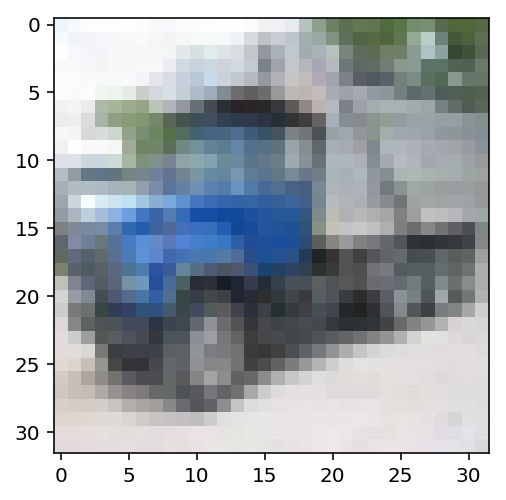

In [3]:
# Visualize sample
def load_label_names():
    return ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  
def load_cfar10_batch(cifar10_dataset_folder_path, batch_id):
    with open(cifar10_dataset_folder_path + '/data_batch_' + str(batch_id), mode='rb') as file:
        # note the encoding type is 'latin1'
        batch = pickle.load(file, encoding='latin1')
        
    features = batch['data'].reshape((len(batch['data']), 3, 32, 32)).transpose(0, 2, 3, 1)
    labels = batch['labels']
        
    return features, labels
  
def display_stats(cifar10_dataset_folder_path, batch_id, sample_id):
    features, labels = load_cfar10_batch(cifar10_dataset_folder_path, batch_id)
    
    if not (0 <= sample_id < len(features)):
        print('{} samples in batch {}.  {} is out of range.'.format(len(features), batch_id, sample_id))
        return None

    print('\nStats of batch #{}:'.format(batch_id))
    print('# of Samples: {}\n'.format(len(features)))
    
    label_names = load_label_names()
    label_counts = dict(zip(*np.unique(labels, return_counts=True)))
    for key, value in label_counts.items():
        print('Label Counts of [{}]({}) : {}'.format(key, label_names[key].upper(), value))
    
    sample_image = features[sample_id]
    sample_label = labels[sample_id]
    
    print('\nExample of Image {}:'.format(sample_id))
    print('Image - Min Value: {} Max Value: {}'.format(sample_image.min(), sample_image.max()))
    print('Image - Shape: {}'.format(sample_image.shape))
    print('Label - Label Id: {} Name: {}'.format(sample_label, label_names[sample_label]))
    
    plt.imshow(sample_image)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Explore the dataset
batch_id = 2
sample_id = 3000
display_stats(cifar10_dataset_folder_path, batch_id, sample_id)

In [6]:
# Generate X, y datasets
n_batches = 5
X = []
y = []

for batch_i in range(1, n_batches + 1):
    index_of_validation = int(len(X))
    features, labels = load_cfar10_batch(cifar10_dataset_folder_path, batch_i)
    X.extend(features[-index_of_validation:])
    y.extend(labels[-index_of_validation:])

print("Data size: {} images".format(len(y)))

Data size: 50000 images


In [7]:
# create 2 datasets with one dataset having classes from 0 to 4 and other having classes from 5 to 9
X_0_4 = np.array([X[i] for i, x in enumerate(y) if x < 5])
y_0_4 = np.array([y[i] for i, x in enumerate(y) if x < 5])
X_5_9 = np.array([X[i] for i, x in enumerate(y) if x >= 5])
y_5_9 = np.array([y[i] for i, x in enumerate(y) if x >= 5])
print("Filtered data size (0-4): {} images".format(len(y_0_4)))
print("Filtered data size (5-9): {} images".format(len(y_5_9)))

Filtered data size (0-4): 25000 images
Filtered data size (5-9): 25000 images


In [8]:
# Split dataset of interest (labels 0-4)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_0_4, y_0_4, test_size=0.20, random_state=42)
print("Training data size (0-4): {} images".format(len(y_train)))

Training data size (0-4): 20000 images


In [9]:
# Evaluate input shape
print("Input shape: {}".format(X_train.shape))
X_train.shape

Input shape: (20000, 32, 32, 3)


(20000, 32, 32, 3)

### 2. Use One-hot encoding to divide y_train and y_test into required no of output classes

In [10]:
import  tensorflow as tf
import keras
y_train = tf.keras.utils.to_categorical(y_train)
y_test  = tf.keras.utils.to_categorical(y_test)

Using TensorFlow backend.


### 3. Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset with at least 80% accuracy on test data

In [0]:
# Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset
# Initialize a sequential model
tf.keras.backend.clear_session()

# Initialize model, reshape & normalize the data
model = tf.keras.models.Sequential()

# Reshape the data
model.add(tf.keras.layers.Reshape(target_shape=(32,32,3), input_shape=(32,32,3))) # RESHAPE

# Normalize the data
model.add(tf.keras.layers.BatchNormalization()) # NORMALIZATION

# Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, # Num of convolutional feature-maps or num of filters
                                 kernel_size=(3,3), # Filter size
                                 activation='relu'))

# Add 2nd Convolutional layer
model.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))

# Add MaxPooling layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

# Flatten the output
model.add(tf.keras.layers.Flatten())

# Add first Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

# Add Droput layer
model.add(tf.keras.layers.Dropout(rate=0.2))

# Add output layer
model.add(tf.keras.layers.Dense(5, activation='softmax'))

In [18]:
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 32, 32, 3)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 32, 32, 3)         12        
_________________________________________________________________
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 12544)             0         
_________________________________________________________________
dense (Dense)                (None, 128)               1

In [0]:
# Need at least 80% accuracy on test data
# Early stopping
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_acc', baseline=0.8, patience=100)

# ModelCheckpoint
from keras.callbacks import ModelCheckpoint
mc = ModelCheckpoint('best_model.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

In [20]:
# Fit model
model.fit(X_train, y_train, batch_size=128, 
          validation_data=(X_test, y_test), shuffle=True, epochs=100, callbacks=[es, mc])

Train on 20000 samples, validate on 5000 samples
Epoch 1/100
19968/20000 [============================>.] - ETA: 0s - loss: 1.3379 - acc: 0.4508
Epoch 00001: val_acc improved from -inf to 0.51520, saving model to best_model.h5
20000/20000 [==============================] - 70s 4ms/sample - loss: 1.3373 - acc: 0.4511 - val_loss: 1.2128 - val_acc: 0.5152
Epoch 2/100
19968/20000 [============================>.] - ETA: 0s - loss: 1.1192 - acc: 0.5571
Epoch 00002: val_acc improved from 0.51520 to 0.59000, saving model to best_model.h5
20000/20000 [==============================] - 71s 4ms/sample - loss: 1.1186 - acc: 0.5573 - val_loss: 1.0575 - val_acc: 0.5900
Epoch 3/100
19968/20000 [============================>.] - ETA: 0s - loss: 1.0063 - acc: 0.6025
Epoch 00003: val_acc improved from 0.59000 to 0.59400, saving model to best_model.h5
20000/20000 [==============================] - 70s 4ms/sample - loss: 1.0060 - acc: 0.6026 - val_loss: 1.0370 - val_acc: 0.5940
Epoch 4/100
19968/20000 [==

In [21]:
# Evaluate model
# load the saved model
saved_model = tf.keras.models.load_model('best_model.h5')

# evaluate the model
_, train_acc = saved_model.evaluate(X_train, y_train, verbose=0)
_, test_acc = saved_model.evaluate(X_test, y_test, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Train: 1.000, Test: 0.775


### 4. In the model which was built above (for classification of classes 0-4 in CIFAR10), make only the dense layers to be trainable and conv layers to be non-trainable

In [22]:
# Transfer learning 
# Load pretrained model
baseModel = tf.keras.models.load_model('best_model.h5')

# show a summary of the base model
print("[INFO] summary for base model...")
print(baseModel.summary())

[INFO] summary for base model...
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 32, 32, 3)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 32, 32, 3)         12        
_________________________________________________________________
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 12544)             0         
_________________________________________________________________
dense (Dense)          

In [0]:
# Make only dense layers trainable
def layer_output(model, layer_name=None):
  """
  Output tensor of a specific layer in a model.
  """
  conv_index = -1

  for i in range(len(model.layers) - 1, -1, -1):
      layer = model.layers[i]
      if layer_name in layer.name:
          conv_index = i
          break

  if conv_index < 0:
      print('Error: could not find the interested layer.')

  return model.layers[conv_index].output

# construct the head of the model that will be placed on top of the the base model
headModel = layer_output(baseModel, 'max_pooling2d')

### 5. Utilize the the model trained on CIFAR 10 (classes 0 to 4) to classify the classes 5 to 9 of CIFAR 10  (Use Transfer Learning) <br>
Achieve an accuracy of more than 85% on test data

In [24]:
# Prepare data for classes 5 to 9
# Split data to train and test
X_train, X_test, y_train, y_test = train_test_split(X_5_9, y_5_9, test_size=0.20, random_state=42)
print("Training data size (5-9): {} images".format(len(y_train)))

Training data size (5-9): 20000 images


In [0]:
# Use One-hot encoding to divide y_train and y_test into required no of output classes
# Restructure labels for one-hot encoding
y_train = y_train - 5
y_test = y_test - 5

# One-hot encoder
y_train = tf.keras.utils.to_categorical(y_train)
y_test  = tf.keras.utils.to_categorical(y_test)

In [26]:
# Flatten the output
headModel = tf.keras.layers.Flatten()(headModel)

headModel = tf.keras.layers.Dense(128, activation='relu')(headModel)
headModel = tf.keras.layers.Dropout(0.2)(headModel)
headModel = tf.keras.layers.Dense(5, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.01))(headModel)

# place the head FC model on top of the base model (this will become the actual model we will train)
model_new = tf.keras.models.Model(inputs=baseModel.input, outputs=headModel)

# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
    layer.trainable = False
    
# compile our model (this needs to be done after our setting our layers to being non-trainable)
model_new.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
# summarize layers
print(model_new.summary())

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape_input (InputLayer)   [(None, 32, 32, 3)]       0         
_________________________________________________________________
reshape (Reshape)            (None, 32, 32, 3)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 32, 32, 3)         12        
_________________________________________________________________
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 12544)             0     

In [27]:
# Need at least 85% accuracy on test data
# Early stopping
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_acc', baseline=0.85, patience=25)

# ModelCheckpoint
from keras.callbacks import ModelCheckpoint
mc = ModelCheckpoint('best_model_2.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

model_new.fit(X_train, y_train, batch_size=128, 
          validation_data=(X_test, y_test), shuffle=True, epochs=25, callbacks=[mc])

Train on 20000 samples, validate on 5000 samples
Epoch 1/25
19968/20000 [============================>.] - ETA: 0s - loss: 1.3020 - acc: 0.5920
Epoch 00001: val_acc improved from -inf to 0.62260, saving model to best_model_2.h5
20000/20000 [==============================] - 24s 1ms/sample - loss: 1.3015 - acc: 0.5921 - val_loss: 1.0188 - val_acc: 0.6226
Epoch 2/25
19968/20000 [============================>.] - ETA: 0s - loss: 0.7883 - acc: 0.7367
Epoch 00002: val_acc improved from 0.62260 to 0.67040, saving model to best_model_2.h5
20000/20000 [==============================] - 23s 1ms/sample - loss: 0.7883 - acc: 0.7366 - val_loss: 0.9109 - val_acc: 0.6704
Epoch 3/25
19968/20000 [============================>.] - ETA: 0s - loss: 0.6848 - acc: 0.7777
Epoch 00003: val_acc improved from 0.67040 to 0.79260, saving model to best_model_2.h5
20000/20000 [==============================] - 23s 1ms/sample - loss: 0.6848 - acc: 0.7777 - val_loss: 0.6461 - val_acc: 0.7926
Epoch 4/25
19968/20000 [

In [28]:
# Evaluate model
# load the saved model
saved_model = tf.keras.models.load_model('best_model_2.h5')

# evaluate the model
_, train_acc = saved_model.evaluate(X_train, y_train, verbose=0)
_, test_acc = saved_model.evaluate(X_test, y_test, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Train: 0.979, Test: 0.838


# Text classification using TF-IDF

### 6. Load the dataset from sklearn.datasets

In [0]:
from sklearn.datasets import fetch_20newsgroups

In [0]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

### 7. Training data

In [31]:
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

### 8. Test data

In [0]:
twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

###  a.  You can access the values for the target variable using .target attribute 
###  b. You can access the name of the class in the target variable with .target_names


In [33]:
twenty_train.target

array([1, 1, 3, ..., 2, 2, 2])

In [34]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [35]:
twenty_train.data[0:5]

['From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n',
 "From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\nSubject: help: Splitting a trimming region along a mesh \nOrganization: University Of Kentucky, Dept. of Math Sciences\nLines: 28\n\n\n\n\tHi,\n\n\tI have a problem, I hope some of the 'gurus' can help me solve.\n\n\tBackground of the probl

### 9.  Now with dependent and independent data available for both train and test datasets, using TfidfVectorizer fit and transform the training data and test data and get the tfidf features for both

In [39]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Use TfidfVectorizer fit and transform the training data and test data and get the tfidf features for both
vect = TfidfVectorizer(max_df=0.8, min_df=0.2)
X_train = vect.fit_transform(twenty_train.data)
X_test = vect.transform(twenty_test.data)

y_train = twenty_train.target
y_test = twenty_test.target

print("Training data shape: {}".format(X_train.shape))
print("Test data shape: {}".format(X_test.shape))

Training data shape: (2257, 95)
Test data shape: (1502, 95)


### 10. Use logisticRegression with tfidf features as input and targets as output and train the model and report the train and test accuracy score

In [40]:
# Use logisticRegression with tfidf features as input and targets as output and train the model
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression

seed = 7
cross_validation_folds = 10

# Model fit
LogReg = LogisticRegression()
LogReg.fit(X_train,y_train)

# Hyperparameter search through grid search
parameter={'penalty' : ['l2','none'], 'C' : [0.1,1,10], 'random_state' : [7], 'multi_class' : ['multinomial'], 
           'solver' : ['newton-cg','lbfgs','sag','saga'], 'n_jobs' : [-1]}

LogReg_GS=GridSearchCV(LogReg,parameter,cv=cross_validation_folds,verbose=1)
        
LogReg_GS.fit(X_train,y_train)
print("Best cross-validation score w/ kfold: {:.2f}".format(LogReg_GS.best_score_))
print("Best parameters: ", LogReg_GS.best_params_)

Fitting 10 folds for each of 24 candidates, totalling 240 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 240 out of 240 | elapsed:  1.5min finished


Best cross-validation score w/ kfold: 0.65
Best parameters:  {'C': 0.1, 'multi_class': 'multinomial', 'n_jobs': -1, 'penalty': 'none', 'random_state': 7, 'solver': 'newton-cg'}


In [41]:
# report the train and test accuracy score
from sklearn.metrics import accuracy_score
y_predict_train = LogReg_GS.predict(X_train)
y_predict_test = LogReg_GS.predict(X_test)
print("Training accuracy score: {}".format(accuracy_score(y_train, y_predict_train)))
print("Test accuracy score: {}".format(accuracy_score(y_test, y_predict_test)))

Training accuracy score: 0.720425343376163
Test accuracy score: 0.611185086551265


In [42]:
# Confusion matrix
GS_cm_train = confusion_matrix(y_train, y_predict_train)
GS_cm_test = confusion_matrix(y_test, y_predict_test)
print("Confusion matrix (train):")
print(GS_cm_train)
print("Confusion matrix (test):")
print(GS_cm_test)

Confusion matrix (train):
[[302  25  71  82]
 [ 22 449  89  24]
 [ 38  97 405  54]
 [ 48  34  47 470]]
Confusion matrix (test):
[[157  22  74  66]
 [ 21 279  65  24]
 [ 50 130 189  27]
 [ 20  28  57 293]]
